# Pengenalan Aksara Jawa 120 Kelas - VGG-16
## Handwritten Javanese Script Recognition (revisi New_Model)

Transfer learning 2 fase pada dataset Indonesian Local Script Characters dengan ketidakseimbangan alami **IR 33.10x** (695 vs 21 gambar/kelas).

**Strategi penanganan imbalance:**
1. Targeted augmentation OFFLINE (hanya 100 kelas non-A -> 300/kelas) + augmentasi online ringan (non-geometris).
2. Weighted CrossEntropyLoss (bobot post-augmentasi) + Label Smoothing 0.1.
3. Seleksi model & scheduler berbasis **macro-F1**.

**Hyperparameter khusus VGG-16 (terbaik, tidak disamakan):**

| Param | Nilai |
|---|---|
| Optimizer | SGD |
| LR Fase 1 / Fase 2 | 0.001 / 0.0001 |
| Weight decay | 0.0005 |
| Batch size | 16 |
| Dropout head | 0.5 |
| Warmup | - |
| Gradient clip | 2.0 |
| Epoch F1/F2 | 10/90 |
| Patience (macro-F1) | 20 |

Evaluasi: 6 kelompok vokal (A/E/I/O/U/E-taling), Top-1/Top-5, macro-F1, CLR (ha/la, sa/da), confusion matrix, visualisasi prediksi.


In [1]:
# =====================================================================
# Cell 1: Setup, Konfigurasi, Reproducibility, AMP, Paths
# =====================================================================
import os, json, time, random
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score,
                             precision_recall_fscore_support)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# ----- CONFIG khusus arsitektur ini -----
CONFIG = {'arch': 'VGG-16', 'optimizer': 'sgd', 'lr_phase1': 0.001, 'lr_phase2': 0.0001, 'weight_decay': 0.0005, 'batch_size': 16, 'dropout': 0.5, 'warmup_epochs': 0, 'grad_clip': 2.0, 'epochs_phase1': 10, 'epochs_phase2': 90, 'patience': 20, 'label_smoothing': 0.1}
SEED = 42

# ----- Reproducibility penuh -----
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

def seed_worker(worker_id):
    ws = torch.initial_seed() % (2**32)
    np.random.seed(ws); random.seed(ws)
g = torch.Generator(); g.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

# ----- AMP (kompatibel torch lama/baru) -----
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def amp_autocast(): return _autocast("cuda", enabled=use_amp)
    scaler = _GradScaler("cuda", enabled=use_amp)
except Exception:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def amp_autocast(): return _autocast(enabled=use_amp)
    scaler = _GradScaler(enabled=use_amp)

print("Device:", device, "| AMP:", use_amp)

# ----- Paths (cari output_pipeline secara otomatis) -----
def find_output_root():
    for cand in [Path("output_pipeline"), Path("../output_pipeline"),
                 Path("../../output_pipeline")]:
        if cand.exists():
            return cand
    return Path("../output_pipeline")
OUTPUT_ROOT  = find_output_root()
TRAIN_DIR    = OUTPUT_ROOT / "augmented_train"
VAL_DIR      = OUTPUT_ROOT / "split" / "val"
TEST_DIR     = OUTPUT_ROOT / "split" / "test"
WEIGHTS_FILE = OUTPUT_ROOT / "class_weights.json"

RESULTS_DIR     = Path("results_" + CONFIG["arch"].lower().replace("-", "_"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = RESULTS_DIR / "best_model.pth"
HISTORY_PATH    = RESULTS_DIR / "training_history.json"
REPORT_PATH     = RESULTS_DIR / "evaluation_report.json"
print("Output pipeline:", OUTPUT_ROOT.resolve())
print("Results dir    :", RESULTS_DIR.resolve())


Device: cuda | AMP: True
Output pipeline: D:\Train Data\computer-vision-project\output_pipeline
Results dir    : D:\Train Data\computer-vision-project\New_Model\results_vgg_16


In [2]:
# =====================================================================
# Cell 2: Transforms & Augmentasi
# ---------------------------------------------------------------------
# Augmentasi TARGETED OFFLINE (1-3 transform acak, hanya non-A -> 300/kelas)
# sudah dijalankan oleh jawa_pipeline.py dan tersimpan di augmented_train/.
# Di sini hanya ditambah augmentasi ONLINE ringan (fotometrik) yang TETAP
# NON-GEOMETRIS sesuai Tabel II paper (tanpa rotasi/flip/shear).
# =====================================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # online, non-geometris
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("Transforms siap (train: + ColorJitter online non-geometris).")


Transforms siap (train: + ColorJitter online non-geometris).


In [3]:
# =====================================================================
# Cell 3: Dataset & DataLoader (batch per-model, deterministik)
# =====================================================================
train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transforms)
val_dataset   = datasets.ImageFolder(str(VAL_DIR),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(str(TEST_DIR),  transform=eval_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)

num_workers = 0 if os.name == "nt" else 4
common = dict(num_workers=num_workers, worker_init_fn=seed_worker,
              generator=g, pin_memory=(device.type == "cuda"))
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=True,  **common)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"],
                          shuffle=False, **common)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"],
                          shuffle=False, **common)

print(f"Kelas : {num_classes} | Train: {len(train_dataset):,} | "
      f"Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
assert num_classes == 120, f"Diharapkan 120 kelas, ditemukan {num_classes}"


Kelas : 120 | Train: 38,510 | Val: 1,789 | Test: 1,919


In [4]:
# =====================================================================
# Cell 4: Pemetaan kelompok vokal (robust, menangani Unicode E-taling)
# =====================================================================
VOWEL_GROUPS  = ["Vokal A", "Vokal E", "Vokal I", "Vokal O", "Vokal U", "Vokal \u00c8"]
GROUP_DISPLAY = {"Vokal A": "A", "Vokal E": "E", "Vokal I": "I",
                 "Vokal O": "O", "Vokal U": "U", "Vokal \u00c8": "E-taling"}

def infer_vowel_group(cls_name):
    for vg in VOWEL_GROUPS:
        short = vg.replace("Vokal ", "")
        if cls_name.startswith(vg + "_") or cls_name.startswith(short + "_"):
            return vg
    return "Unknown"

vowel_of_class = {c: infer_vowel_group(c) for c in class_names}
dist = Counter(vowel_of_class.values())
print("Distribusi kelas per kelompok vokal:")
for vg in VOWEL_GROUPS:
    print(f"  {GROUP_DISPLAY[vg]:9s}: {dist.get(vg, 0)} kelas")
if dist.get("Unknown", 0):
    print("  PERINGATAN: ada kelas tak terpetakan:", dist["Unknown"])


Distribusi kelas per kelompok vokal:
  A        : 20 kelas
  E        : 20 kelas
  I        : 20 kelas
  O        : 20 kelas
  U        : 20 kelas
  E-taling : 20 kelas


In [5]:
# =====================================================================
# Cell 5: Class Weights (bobot post-augmentasi, Pers.1 paper)
# =====================================================================
with open(WEIGHTS_FILE, "r", encoding="utf-8") as f:
    meta = json.load(f)
class_to_idx_file = meta["class_to_idx"]
weight_dict       = meta["class_weights"]

# Guard: urutan kelas ImageFolder HARUS sama dengan class_weights.json
idx_to_class = {v: k for k, v in class_to_idx_file.items()}
file_order   = [idx_to_class[i] for i in range(len(idx_to_class))]
assert file_order == class_names, (
    "Urutan kelas ImageFolder != class_weights.json! Bobot bisa tertukar.")

weight_tensor = torch.zeros(num_classes)
for cname, idx in class_to_idx_file.items():
    weight_tensor[idx] = weight_dict[cname]
class_weights = weight_tensor.to(device)
print(f"Class weights dimuat. min={weight_tensor.min():.4f} "
      f"max={weight_tensor.max():.4f} ratio={weight_tensor.max()/weight_tensor.min():.2f}x")


Class weights dimuat. min=0.6603 max=1.0697 ratio=1.62x


In [6]:
# =====================================================================
# Cell 6: Loss = Weighted CrossEntropy + Label Smoothing
# (opsi ablation: Focal Loss / Class-Balanced Loss di bawah)
# =====================================================================
criterion = nn.CrossEntropyLoss(weight=class_weights,
                                label_smoothing=CONFIG["label_smoothing"])

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__(); self.weight = weight; self.gamma = gamma
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# --- Untuk ablation, aktifkan salah satu: ---
# criterion = FocalLoss(weight=class_weights, gamma=2.0)
print("Loss:", criterion.__class__.__name__,
      "| label_smoothing:", CONFIG["label_smoothing"])


Loss: CrossEntropyLoss | label_smoothing: 0.1


In [7]:
# =====================================================================
# Cell 7: Inisialisasi Model (transfer learning, pretrained ImageNet-1K)
# =====================================================================
def build_model(arch, num_classes, dropout):
    a = arch.lower()
    if a == "efficientnet-b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, num_classes))
    elif a == "mobilenetv3-large":
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        in_f = m.classifier[3].in_features
        m.classifier[2] = nn.Dropout(p=dropout)
        m.classifier[3] = nn.Linear(in_f, num_classes)
    elif a == "resnet-18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_f = m.fc.in_features
        m.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, num_classes))
    elif a == "vgg-16":
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        in_f = m.classifier[6].in_features
        m.classifier[2] = nn.Dropout(p=dropout)
        m.classifier[5] = nn.Dropout(p=dropout)
        m.classifier[6] = nn.Linear(in_f, num_classes)
    else:
        raise ValueError("Arsitektur tidak dikenal: " + arch)
    return m

model = build_model(CONFIG["arch"], num_classes, CONFIG["dropout"]).to(device)
total_p = sum(p.numel() for p in model.parameters())
print(f"{CONFIG['arch']} dimuat | total parameter: {total_p:,} (~{total_p/1e6:.1f}M)")


VGG-16 dimuat | total parameter: 134,752,184 (~134.8M)


In [8]:
# =====================================================================
# Cell 8: Helper Training (EarlyStopping macro-F1, AMP, grad-clip)
# =====================================================================
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0, mode="max"):
        self.patience = patience; self.min_delta = min_delta; self.mode = mode
        self.best = -float("inf") if mode == "max" else float("inf")
        self.counter = 0; self.early_stop = False
    def __call__(self, metric):
        improve = (metric > self.best + self.min_delta) if self.mode == "max" \
                  else (metric < self.best - self.min_delta)
        if improve:
            self.best = metric; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def macro_f1_groups(labels, preds):
    labels = np.array(labels); preds = np.array(preds)
    f1_all = f1_score(labels, preds, average="macro")
    groups = {}
    for vg in VOWEL_GROUPS:
        idxs = [i for i, c in enumerate(class_names) if vowel_of_class[c] == vg]
        mask = np.isin(labels, idxs)
        if mask.sum() > 0:
            groups[vg] = f1_score(labels[mask], preds[mask], average="macro")
    return f1_all, groups

def train_epoch(model, loader, criterion, optimizer, grad_clip=None):
    model.train(); running = 0.0; correct = 0; total = 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        with amp_autocast():
            out = model(images); loss = criterion(out, targets)
        scaler.scale(loss).backward()
        if grad_clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        running += loss.item() * images.size(0)
        correct += out.argmax(1).eq(targets).sum().item(); total += targets.size(0)
    return running / total, correct / total

def evaluate(model, loader, criterion):
    model.eval(); running = 0.0; correct = 0; total = 0; P = []; L = []
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            with amp_autocast():
                out = model(images); loss = criterion(out, targets)
            running += loss.item() * images.size(0)
            preds = out.argmax(1)
            correct += preds.eq(targets).sum().item(); total += targets.size(0)
            P.extend(preds.cpu().numpy()); L.extend(targets.cpu().numpy())
    f1, groups = macro_f1_groups(L, P)
    return running / total, correct / total, f1, groups

def make_optimizer(params, cfg, lr):
    if cfg["optimizer"] == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=cfg["weight_decay"])
    if cfg["optimizer"] == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, nesterov=True,
                         weight_decay=cfg["weight_decay"])
    raise ValueError(cfg["optimizer"])
print("Helper training siap.")


Helper training siap.


In [9]:
# =====================================================================
# Cell 9: FASE 1 - Feature Extraction (latih classifier head saja)
# =====================================================================
for p in model.parameters():
    p.requires_grad = False
head = model.classifier if hasattr(model, "classifier") else model.fc
for p in head.parameters():
    p.requires_grad = True

optimizer = make_optimizer(filter(lambda p: p.requires_grad, model.parameters()),
                           CONFIG, CONFIG["lr_phase1"])

history = {"train_loss": [], "train_acc": [], "val_loss": [],
           "val_acc": [], "val_f1": []}

print("=== FASE 1: Feature Extraction (head only) ===")
for epoch in range(CONFIG["epochs_phase1"]):
    t0 = time.time()
    tl, ta = train_epoch(model, train_loader, criterion, optimizer, CONFIG["grad_clip"])
    vl, va, vf, _ = evaluate(model, val_loader, criterion)
    for k, v in zip(["train_loss","train_acc","val_loss","val_acc","val_f1"],
                    [tl, ta, vl, va, vf]):
        history[k].append(v)
    print(f"[P1 {epoch+1:02d}/{CONFIG['epochs_phase1']}] ({time.time()-t0:.0f}s) "
          f"train_loss {tl:.4f} acc {ta*100:.2f}% | "
          f"val_loss {vl:.4f} acc {va*100:.2f}% macroF1 {vf:.4f}")


=== FASE 1: Feature Extraction (head only) ===
[P1 01/10] (691s) train_loss 3.9891 acc 11.23% | val_loss 3.3234 acc 32.08% macroF1 0.1239
[P1 02/10] (342s) train_loss 3.0701 acc 30.65% | val_loss 2.8182 acc 49.64% macroF1 0.2468
[P1 03/10] (332s) train_loss 2.5821 acc 46.12% | val_loss 2.5218 acc 58.36% macroF1 0.3250
[P1 04/10] (329s) train_loss 2.2399 acc 58.61% | val_loss 2.3239 acc 64.78% macroF1 0.3829
[P1 05/10] (331s) train_loss 1.9946 acc 67.94% | val_loss 2.1915 acc 68.81% macroF1 0.4339
[P1 06/10] (340s) train_loss 1.7973 acc 75.89% | val_loss 2.0803 acc 72.39% macroF1 0.4681
[P1 07/10] (328s) train_loss 1.6518 acc 81.38% | val_loss 2.0033 acc 75.35% macroF1 0.5027
[P1 08/10] (322s) train_loss 1.5333 acc 85.55% | val_loss 1.9402 acc 75.96% macroF1 0.4978
[P1 09/10] (324s) train_loss 1.4380 acc 88.50% | val_loss 1.8930 acc 77.47% macroF1 0.5116
[P1 10/10] (328s) train_loss 1.3656 acc 90.68% | val_loss 1.8511 acc 78.37% macroF1 0.5250


In [10]:
# =====================================================================
# Cell 10: FASE 2 - Full Fine-Tuning (unfreeze SEMUA layer)
# Seleksi best model & scheduler berbasis macro-F1. Patience 20.
# =====================================================================
for p in model.parameters():
    p.requires_grad = True
optimizer = make_optimizer(model.parameters(), CONFIG, CONFIG["lr_phase2"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                 factor=0.5, patience=3)
early = EarlyStopping(patience=CONFIG["patience"], mode="max")

best_f1 = -1.0; best_epoch = -1
warmup  = CONFIG["warmup_epochs"] or 0
base_lr = CONFIG["lr_phase2"]

print("=== FASE 2: Full Fine-Tuning ===")
for epoch in range(CONFIG["epochs_phase2"]):
    actual = CONFIG["epochs_phase1"] + epoch + 1
    if warmup and epoch < warmup:                       # linear warmup
        for pg in optimizer.param_groups:
            pg["lr"] = base_lr * (epoch + 1) / warmup
    t0 = time.time()
    tl, ta = train_epoch(model, train_loader, criterion, optimizer, CONFIG["grad_clip"])
    vl, va, vf, _ = evaluate(model, val_loader, criterion)
    if not (warmup and epoch < warmup):
        scheduler.step(vf)
    for k, v in zip(["train_loss","train_acc","val_loss","val_acc","val_f1"],
                    [tl, ta, vl, va, vf]):
        history[k].append(v)
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"[P2 {actual:02d}] ({time.time()-t0:.0f}s) lr {lr_now:.2e} | "
          f"val_loss {vl:.4f} acc {va*100:.2f}% macroF1 {vf:.4f}")
    if vf > best_f1:
        best_f1 = vf; best_epoch = actual
        torch.save(model.state_dict(), str(MODEL_SAVE_PATH))
        print(f"   >> best macroF1 {best_f1:.4f} disimpan (epoch {best_epoch})")
    early(vf)
    if early.early_stop:
        print(f"Early stopping di epoch {actual} "
              f"(best epoch {best_epoch}, macroF1 {best_f1:.4f})")
        break

history["best_epoch"]  = best_epoch
history["best_val_f1"] = best_f1
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("History disimpan:", HISTORY_PATH)


=== FASE 2: Full Fine-Tuning ===
[P2 11] (435s) lr 1.00e-04 | val_loss 1.7106 acc 83.06% macroF1 0.5884
   >> best macroF1 0.5884 disimpan (epoch 11)
[P2 12] (431s) lr 1.00e-04 | val_loss 1.6641 acc 84.68% macroF1 0.6151
   >> best macroF1 0.6151 disimpan (epoch 12)
[P2 13] (434s) lr 1.00e-04 | val_loss 1.6283 acc 86.08% macroF1 0.6308
   >> best macroF1 0.6308 disimpan (epoch 13)
[P2 14] (431s) lr 1.00e-04 | val_loss 1.6015 acc 87.37% macroF1 0.6369
   >> best macroF1 0.6369 disimpan (epoch 14)
[P2 15] (430s) lr 1.00e-04 | val_loss 1.5784 acc 87.81% macroF1 0.6463
   >> best macroF1 0.6463 disimpan (epoch 15)
[P2 16] (431s) lr 1.00e-04 | val_loss 1.5586 acc 88.54% macroF1 0.6520
   >> best macroF1 0.6520 disimpan (epoch 16)
[P2 17] (425s) lr 1.00e-04 | val_loss 1.5439 acc 88.99% macroF1 0.6675
   >> best macroF1 0.6675 disimpan (epoch 17)
[P2 18] (425s) lr 1.00e-04 | val_loss 1.5234 acc 88.88% macroF1 0.6590
[P2 19] (425s) lr 1.00e-04 | val_loss 1.5122 acc 89.49% macroF1 0.6725
   >> 

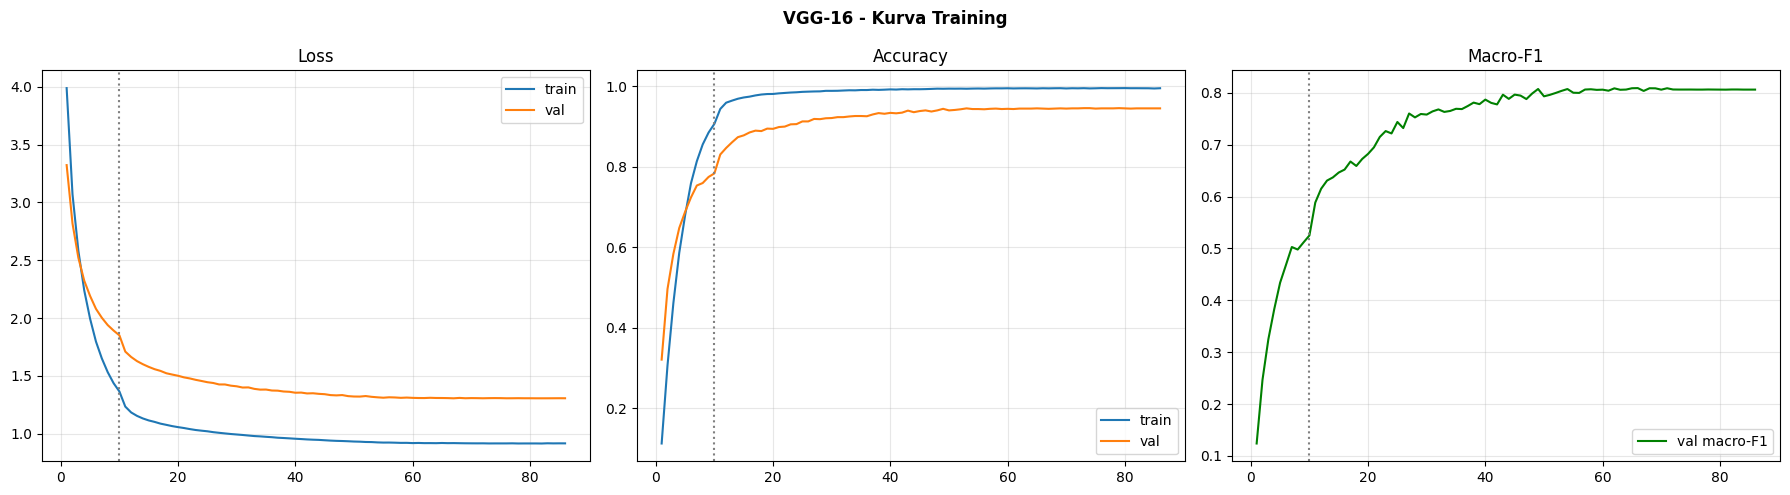

In [11]:
# =====================================================================
# Cell 11: Kurva Training (loss, akurasi, macro-F1)
# =====================================================================
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(ep, history["train_loss"], label="train"); ax[0].plot(ep, history["val_loss"], label="val")
ax[0].axvline(CONFIG["epochs_phase1"], ls=":", c="gray"); ax[0].set_title("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, history["train_acc"], label="train"); ax[1].plot(ep, history["val_acc"], label="val")
ax[1].axvline(CONFIG["epochs_phase1"], ls=":", c="gray"); ax[1].set_title("Accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(ep, history["val_f1"], c="green", label="val macro-F1")
ax[2].axvline(CONFIG["epochs_phase1"], ls=":", c="gray"); ax[2].set_title("Macro-F1"); ax[2].legend(); ax[2].grid(alpha=.3)
fig.suptitle(f"{CONFIG['arch']} - Kurva Training", fontweight="bold")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150); plt.show()


In [12]:
# =====================================================================
# Cell 12: Inferensi Test Set (muat model terbaik)
# =====================================================================
model.load_state_dict(torch.load(str(MODEL_SAVE_PATH)))
model.eval()
all_preds = []; all_labels = []; all_logits = []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        with amp_autocast():
            out = model(images)
        all_logits.append(out.float().cpu())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(targets.numpy())
all_logits = torch.cat(all_logits)
y_true = np.array(all_labels); y_pred = np.array(all_preds)
print("Inferensi test selesai:", len(y_true), "sampel")


Inferensi test selesai: 1919 sampel


In [13]:
# =====================================================================
# Cell 13: Metrik Keseluruhan (Top-1, Top-5, macro/weighted) + CI
# =====================================================================
top1 = accuracy_score(y_true, y_pred) * 100
k = min(5, num_classes)
topk = all_logits.topk(k, dim=1).indices.numpy()
top5 = np.mean([y_true[i] in topk[i] for i in range(len(y_true))]) * 100
f1_macro = f1_score(y_true, y_pred, average="macro")
pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

# Bootstrap 95% CI utk macro-F1 (single-split, tanpa retraining)
rng = np.random.default_rng(SEED); boots = []
for _ in range(1000):
    idx = rng.integers(0, len(y_true), len(y_true))
    boots.append(f1_score(y_true[idx], y_pred[idx], average="macro"))
ci_low, ci_high = np.percentile(boots, [2.5, 97.5])

print(f"Top-1 : {top1:.2f}%")
print(f"Top-5 : {top5:.2f}%")
print(f"macro-F1 : {f1_macro:.4f}  (95% CI {ci_low:.4f} - {ci_high:.4f})")
print(f"Macro    P/R/F1: {pm:.4f}/{rm:.4f}/{fm:.4f}")
print(f"Weighted P/R/F1: {pw:.4f}/{rw:.4f}/{fw:.4f}")


Top-1 : 94.89%
Top-5 : 99.01%
macro-F1 : 0.8326  (95% CI 0.7772 - 0.8472)
Macro    P/R/F1: 0.8593/0.8374/0.8326
Weighted P/R/F1: 0.9549/0.9489/0.9479


F1 macro per kelompok vokal:
  A         (20 kelas, 1518 sampel): acc  98.62%  f1 0.9386
  E         (20 kelas,   81 sampel): acc  72.84%  f1 0.6383
  I         (20 kelas,   80 sampel): acc  93.75%  f1 0.8976
  O         (20 kelas,   80 sampel): acc  65.00%  f1 0.5673
  U         (20 kelas,   80 sampel): acc  90.00%  f1 0.8969
  E-taling  (20 kelas,   80 sampel): acc  82.50%  f1 0.6159

Vokal A (mayoritas) 0.9386  vs  non-A (minoritas) 0.7232 | gap 0.2154


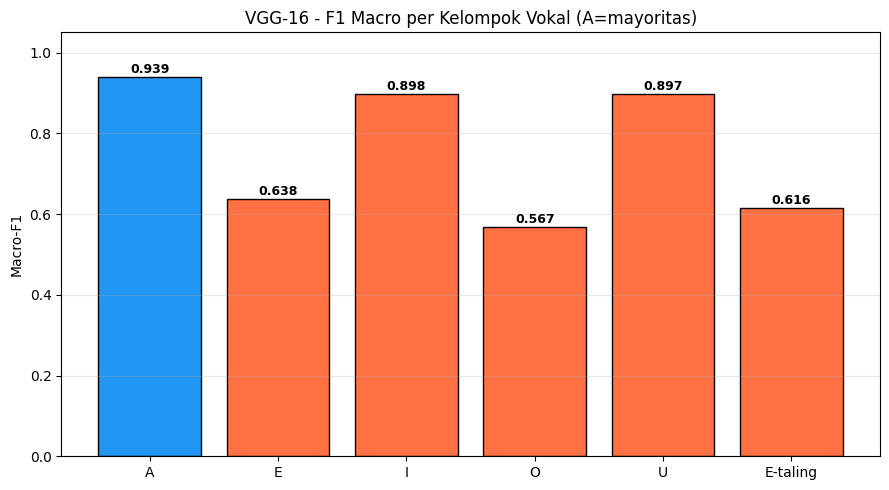

In [14]:
# =====================================================================
# Cell 14: F1 Macro per 6 Kelompok Vokal (A/E/I/O/U/E-taling) + gap
# =====================================================================
group_results = {}
print("F1 macro per kelompok vokal:")
for vg in VOWEL_GROUPS:
    idxs = [i for i, c in enumerate(class_names) if vowel_of_class[c] == vg]
    mask = np.isin(y_true, idxs)
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_true[mask], y_pred[mask]) * 100
    f1  = f1_score(y_true[mask], y_pred[mask], average="macro")
    group_results[vg] = {"n_classes": len(idxs), "n_samples": int(mask.sum()),
                         "accuracy": acc, "f1_macro": f1}
    print(f"  {GROUP_DISPLAY[vg]:9s} ({len(idxs):2d} kelas, {int(mask.sum()):4d} sampel): "
          f"acc {acc:6.2f}%  f1 {f1:.4f}")

f1_A    = group_results.get("Vokal A", {}).get("f1_macro", 0.0)
non_A   = [v["f1_macro"] for kk, v in group_results.items() if kk != "Vokal A"]
f1_nonA = float(np.mean(non_A)) if non_A else 0.0
gap     = abs(f1_A - f1_nonA)
print(f"\nVokal A (mayoritas) {f1_A:.4f}  vs  non-A (minoritas) {f1_nonA:.4f} | gap {gap:.4f}")

gs = list(group_results.keys())
colors = ["#2196F3" if g == "Vokal A" else "#FF7043" for g in gs]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([GROUP_DISPLAY[g] for g in gs],
              [group_results[g]["f1_macro"] for g in gs],
              color=colors, edgecolor="k")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + .01,
            f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.05); ax.set_ylabel("Macro-F1")
ax.set_title(f"{CONFIG['arch']} - F1 Macro per Kelompok Vokal (A=mayoritas)")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "f1_per_vowel.png", dpi=150); plt.show()


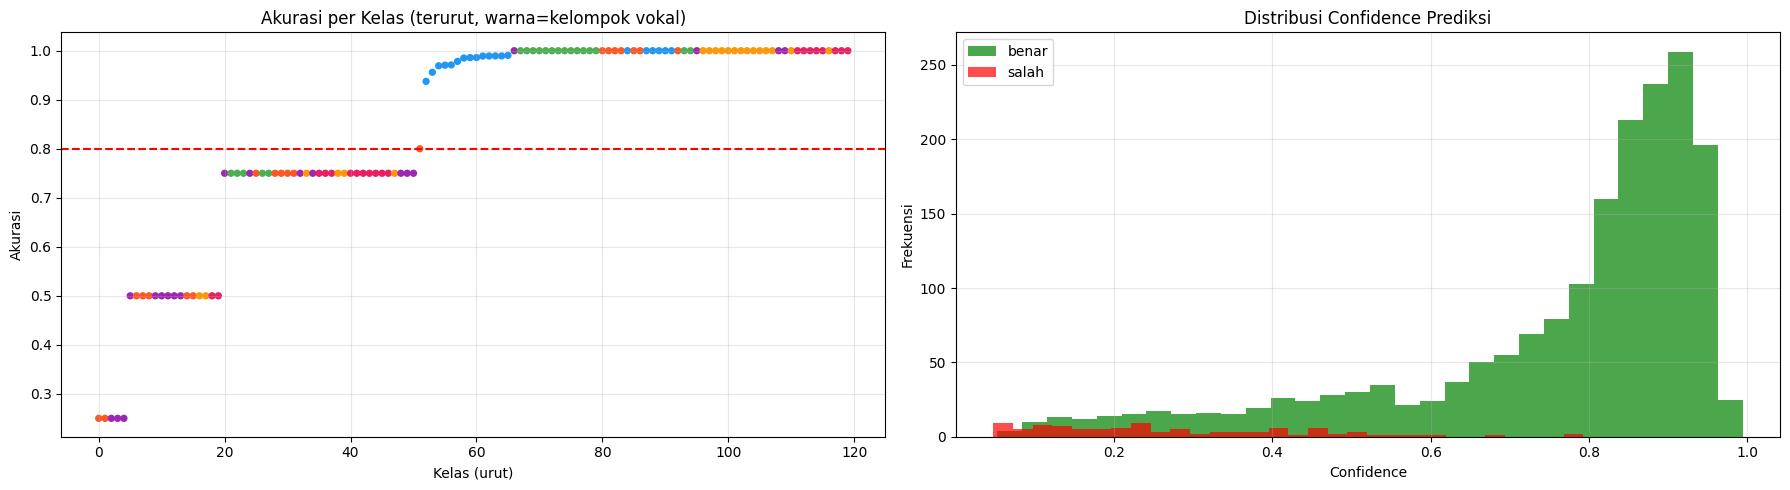

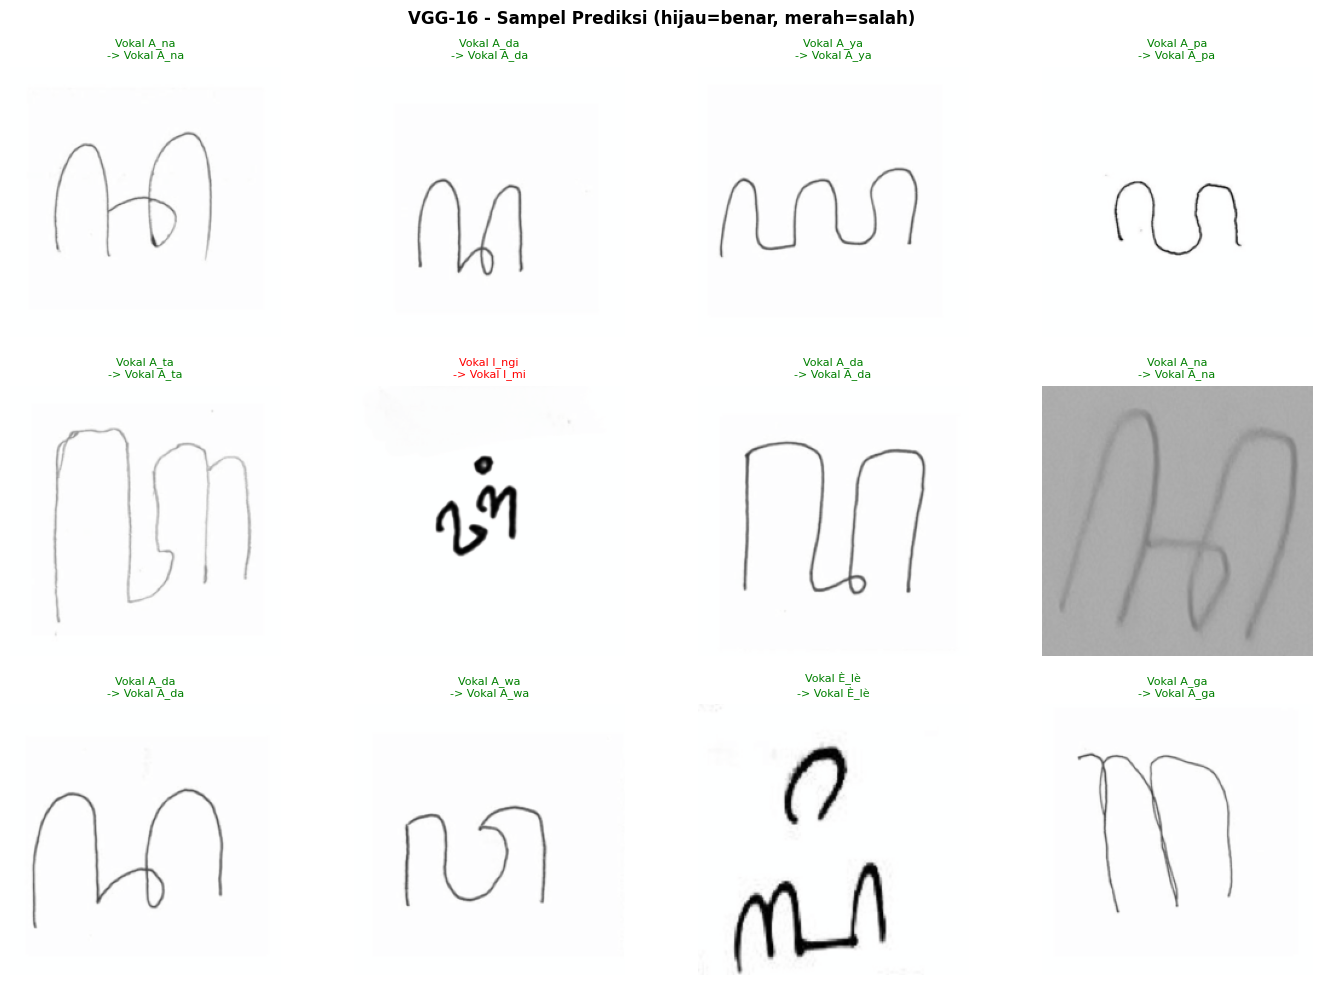

In [15]:
# =====================================================================
# Cell 15: Visualisasi Hasil Prediksi terhadap Dataset
#   (a) kurva akurasi per-kelas  (b) distribusi confidence  (c) grid sampel
# =====================================================================
probs = torch.softmax(all_logits, dim=1).numpy()
conf  = probs.max(1)
correct_mask = (y_pred == y_true)

group_color = {"Vokal A": "#2196F3", "Vokal E": "#FF5722", "Vokal I": "#4CAF50",
               "Vokal O": "#9C27B0", "Vokal U": "#FF9800",
               "Vokal \u00c8": "#E91E63", "Unknown": "#888888"}

per_class_acc = []
for i in range(num_classes):
    m = (y_true == i)
    per_class_acc.append((y_pred[m] == i).mean() if m.sum() > 0 else np.nan)
per_class_acc = np.array(per_class_acc)
order = np.argsort(np.nan_to_num(per_class_acc, nan=1.0))
pt_colors = [group_color[vowel_of_class[class_names[i]]] for i in order]

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].scatter(range(num_classes), per_class_acc[order], c=pt_colors, s=18)
ax[0].axhline(0.8, ls="--", c="red")
ax[0].set_title("Akurasi per Kelas (terurut, warna=kelompok vokal)")
ax[0].set_xlabel("Kelas (urut)"); ax[0].set_ylabel("Akurasi"); ax[0].grid(alpha=.3)
ax[1].hist(conf[correct_mask],  bins=30, alpha=.7, color="green", label="benar")
ax[1].hist(conf[~correct_mask], bins=30, alpha=.7, color="red",   label="salah")
ax[1].set_title("Distribusi Confidence Prediksi")
ax[1].set_xlabel("Confidence"); ax[1].set_ylabel("Frekuensi"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "prediction_analysis.png", dpi=150); plt.show()

# (c) grid sampel (test_loader shuffle=False -> index sejajar dengan y_pred)
n = min(12, len(test_dataset))
sel = np.random.default_rng(SEED).choice(len(test_dataset), n, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(14, 10)); axes = axes.flatten()
for ax_, si in zip(axes, sel):
    img, lab = test_dataset[si]
    show = img.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    ax_.imshow(np.clip(show, 0, 1))
    pr = int(y_pred[si]); ok = (pr == lab)
    ax_.set_title(f"{class_names[lab]}\n-> {class_names[pr]}",
                  color="green" if ok else "red", fontsize=8)
    ax_.axis("off")
fig.suptitle(f"{CONFIG['arch']} - Sampel Prediksi (hijau=benar, merah=salah)", fontweight="bold")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "sample_predictions.png", dpi=150); plt.show()


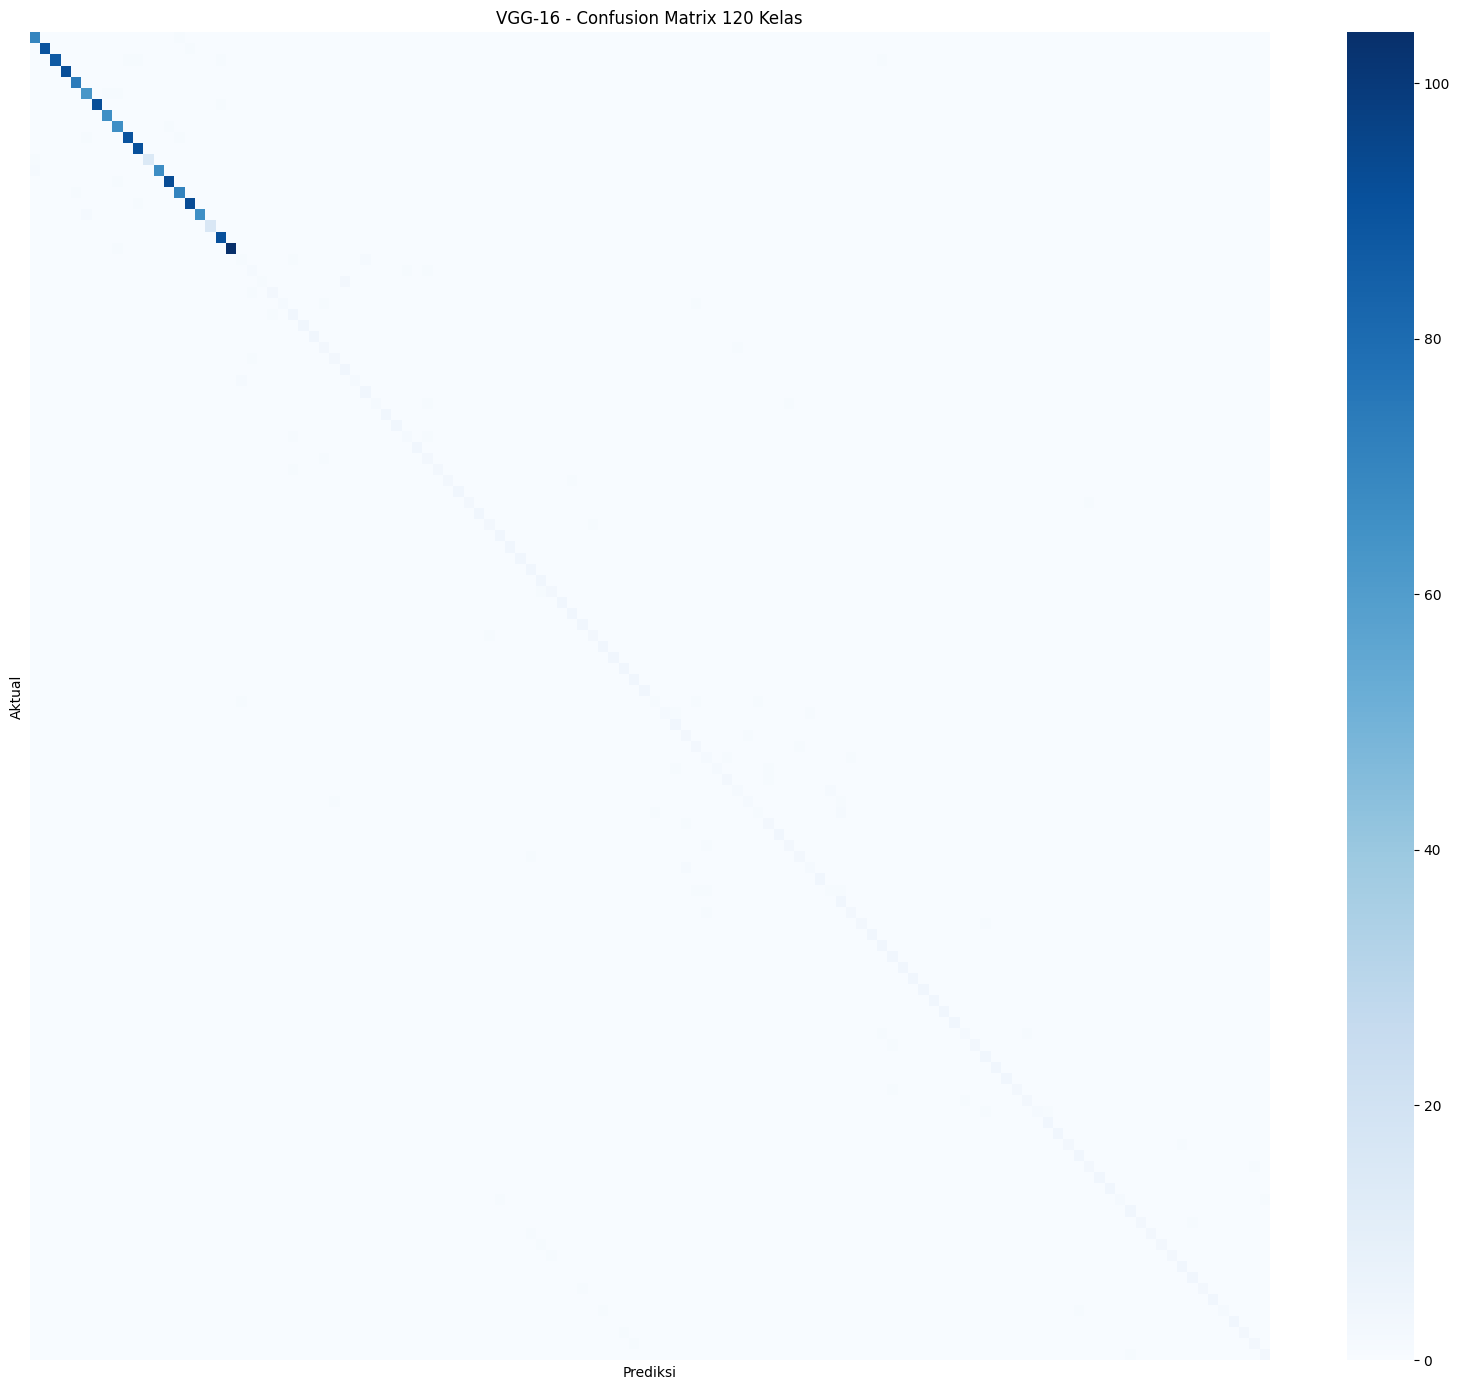

Top-10 pasangan paling konfusif:
  Vokal E_de         -> Vokal E_ne         : 3
  Vokal O_so         -> Vokal O_do         : 2
  Vokal O_ngo        -> Vokal O_wo         : 2
  Vokal O_lo         -> Vokal O_to         : 2
  Vokal E_nge        -> Vokal E_be         : 2
  Vokal E_be         -> Vokal E_nye        : 2
  Vokal A_ta         -> Vokal A_ha         : 2
  Vokal A_nya        -> Vokal A_ba         : 2
  Vokal È_yè         -> Vokal È_jè         : 1
  Vokal È_wè         -> Vokal I_wi         : 1

Character Likeness Rate (CLR):
  ha/la: 0.76%
  sa/da: 0.00%

F1 rata-rata karakter sulit:
  tha: 1.0000 (n=1)
  nga: 0.9677 (n=1)


In [16]:
# =====================================================================
# Cell 16: Confusion Matrix, Pasangan Konfusif, CLR, F1 tha/nga
# =====================================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title(f"{CONFIG['arch']} - Confusion Matrix 120 Kelas")
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150); plt.show()

# Top-10 pasangan konfusif
pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            pairs.append((int(cm[i, j]), class_names[i], class_names[j]))
pairs.sort(reverse=True)
print("Top-10 pasangan paling konfusif:")
for c, a, b in pairs[:10]:
    print(f"  {a:18s} -> {b:18s} : {c}")

# CLR (Character Likeness Rate) untuk pasangan target (Nindya et al.)
def clr(sub_a, sub_b):
    ia = [i for i, c in enumerate(class_names) if c.endswith("_" + sub_a)]
    ib = [i for i, c in enumerate(class_names) if c.endswith("_" + sub_b)]
    confused = sum(cm[i, j] + cm[j, i] for i in ia for j in ib)
    total    = sum(cm[i, :].sum() for i in ia) + sum(cm[j, :].sum() for j in ib)
    return 100.0 * confused / total if total > 0 else 0.0

print("\nCharacter Likeness Rate (CLR):")
for a, b in [("ha", "la"), ("sa", "da")]:
    print(f"  {a}/{b}: {clr(a, b):.2f}%")

# F1 per-karakter sulit (Sulistiyo et al.): tha, nga
rep = classification_report(y_true, y_pred, target_names=class_names,
                            output_dict=True, zero_division=0)
print("\nF1 rata-rata karakter sulit:")
for ch in ["tha", "nga"]:
    fs = [rep[c]["f1-score"] for c in class_names if c.endswith("_" + ch)]
    if fs:
        print(f"  {ch}: {np.mean(fs):.4f} (n={len(fs)})")


In [17]:
# =====================================================================
# Cell 17: Simpan Report (JSON + CSV per-kelas) & Ringkasan
# =====================================================================
import csv
summary = {
    "architecture": CONFIG["arch"], "config": CONFIG,
    "best_epoch": history.get("best_epoch"),
    "top1_accuracy": top1, "top5_accuracy": top5,
    "macro_f1": f1_macro, "macro_f1_ci": [float(ci_low), float(ci_high)],
    "weighted_f1": fw,
    "f1_vokal_A": f1_A, "f1_non_A": f1_nonA, "gap": gap,
    "per_group": group_results,
}
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump({"summary": summary, "full_report": rep}, f, indent=2, ensure_ascii=False)

with open(RESULTS_DIR / "per_class_f1.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["class", "vowel_group", "precision", "recall", "f1", "support"])
    for c in class_names:
        r = rep[c]
        w.writerow([c, vowel_of_class[c], r["precision"], r["recall"],
                    r["f1-score"], r["support"]])

print("=" * 64)
print(f"RINGKASAN AKHIR - {CONFIG['arch']}")
print("=" * 64)
print(f"  Top-1 {top1:.2f}% | Top-5 {top5:.2f}% | macro-F1 {f1_macro:.4f}")
print(f"  Gap A vs non-A: {gap:.4f}  (A {f1_A:.4f} / non-A {f1_nonA:.4f})")
print(f"  Best epoch: {history.get('best_epoch')}")
print("-" * 64)
print("Pembanding prior work:")
print("  Susanto 97.29/99.65% (120 kelas, SEIMBANG)")
print("  Wisesty F1 0.9788 (20 kelas) | Fateah 91% (ResNet-18, 20 kelas)")
print("  Nindya 93.19% (VGG-16, 20 kelas)")
print(f"Report : {REPORT_PATH}")
print(f"CSV    : {RESULTS_DIR / 'per_class_f1.csv'}")


RINGKASAN AKHIR - VGG-16
  Top-1 94.89% | Top-5 99.01% | macro-F1 0.8326
  Gap A vs non-A: 0.2154  (A 0.9386 / non-A 0.7232)
  Best epoch: 66
----------------------------------------------------------------
Pembanding prior work:
  Susanto 97.29/99.65% (120 kelas, SEIMBANG)
  Wisesty F1 0.9788 (20 kelas) | Fateah 91% (ResNet-18, 20 kelas)
  Nindya 93.19% (VGG-16, 20 kelas)
Report : results_vgg_16\evaluation_report.json
CSV    : results_vgg_16\per_class_f1.csv
